In [1]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
iris = load_iris()
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names
print("Original Data Shape:", X.shape)

Original Data Shape: (150, 4)


In [2]:

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

In [3]:
minmax = MinMaxScaler()
X_normalized = minmax.fit_transform(X)



In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)


In [5]:
print("\nExplained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {var:.4f}")

print("\nCumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_))




Explained Variance Ratio:
Principal Component 1: 0.7296
Principal Component 2: 0.2285

Cumulative Explained Variance: [0.72962445 0.95813207]


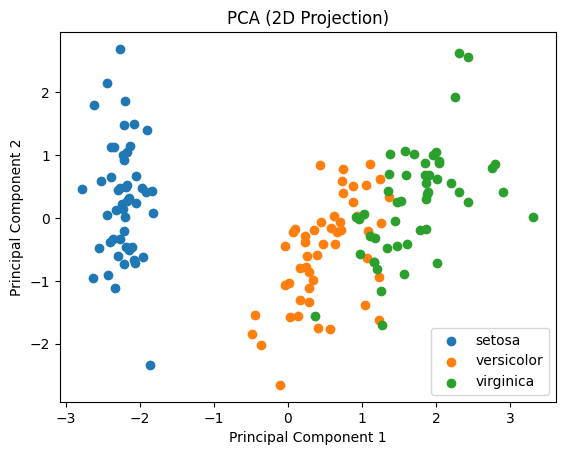

In [6]:
plt.figure()
for i, target in enumerate(target_names):
  plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA (2D Projection)")
plt.legend()
plt.show()


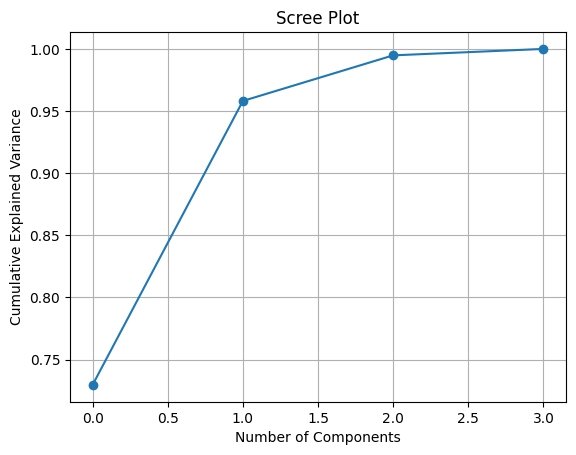

In [7]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_standardized)
plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()



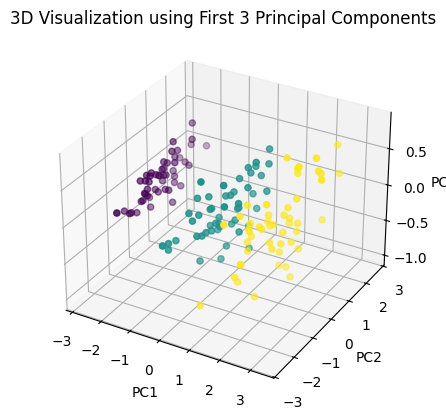

In [8]:

X_scaled = StandardScaler().fit_transform(X)

# PCA with 3 components
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

# 3D Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3[:, 0],
    X_pca_3[:, 1],
    X_pca_3[:, 2],
    c=y
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title("3D Visualization using First 3 Principal Components")
plt.show()

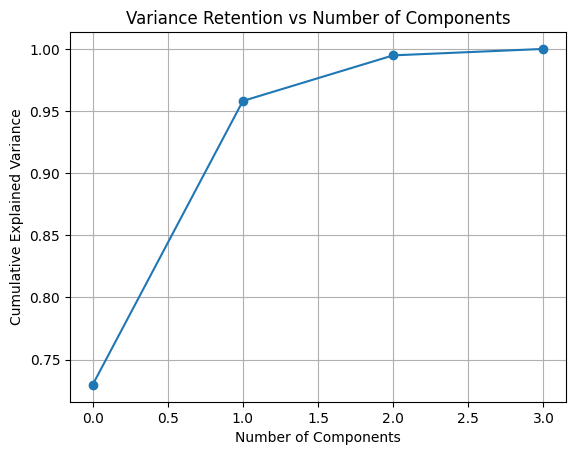

In [9]:

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(explained_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Variance Retention vs Number of Components')
plt.grid()
plt.show()


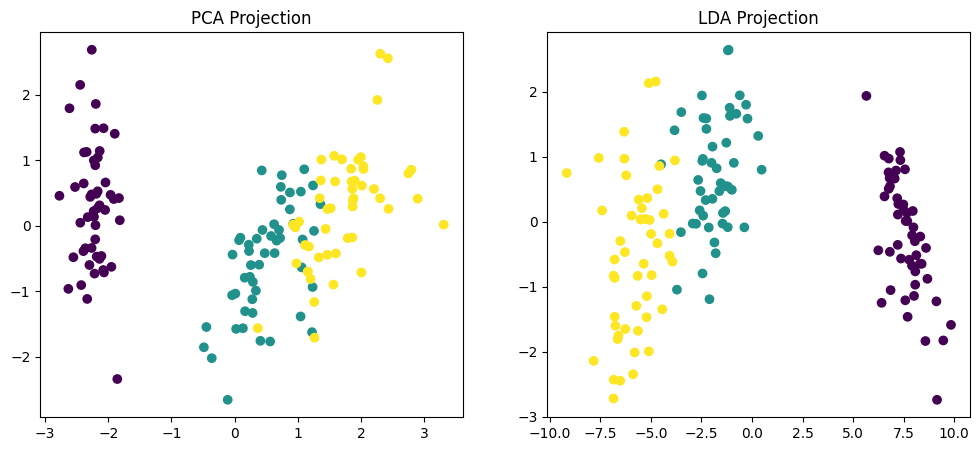

In [10]:


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# LDA (max = classes - 1)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.title("PCA Projection")

plt.subplot(1,2,2)
plt.scatter(X_lda[:,0], X_lda[:,1], c=y)
plt.title("LDA Projection")

plt.show()


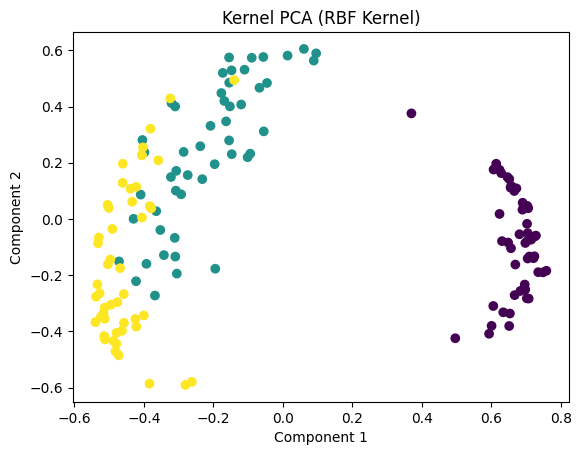

In [11]:

from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
X_kpca = kpca.fit_transform(X_scaled)

plt.scatter(X_kpca[:,0], X_kpca[:,1], c=y)
plt.title("Kernel PCA (RBF Kernel)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()


In [12]:
from sklearn.metrics import mean_squared_error

# Reduce to 2 components
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

# Reconstruct data
X_reconstructed = pca_2.inverse_transform(X_reduced)

# Reconstruction error
error = mean_squared_error(X_scaled, X_reconstructed)
print("Reconstruction Error:", error)


Reconstruction Error: 0.04186792799998359
